In [24]:
import pandas as pd

DATASET_PATH = '../data/enron/enron_spam_data.csv'

df = pd.read_csv(DATASET_PATH)

df.head()

,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


In [25]:
print(f"Rows: {df.shape[0]} , Columns: {df.shape[1]}")


df.isnull().sum()

Rows: 33716 , Columns: 5


Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64

In [ ]:
# Drop missing messages
df = df.dropna(subset=['Message'])

# Fill subject if needed
df['Subject'] = df['Subject'].fillna('')

print(f"Rows: {df.shape[0]} , Columns: {df.shape[1]}")


df.isnull().sum()

Spam/Ham
spam    50.538312
ham     49.461688
Name: proportion, dtype: float64

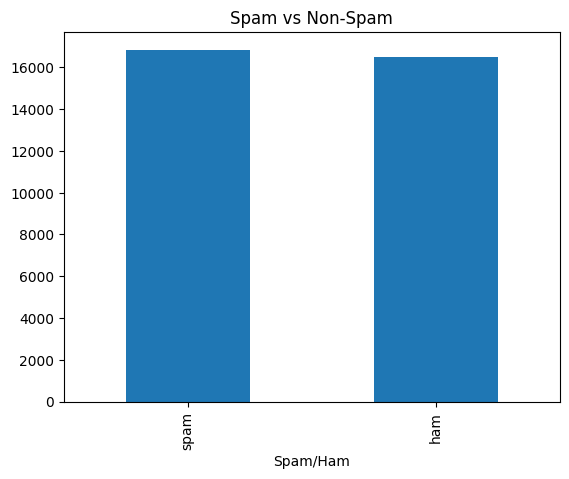

In [27]:
# Spam/Ham column where 1 = spam, 0 = not spam
df['Spam/Ham'].value_counts().plot(kind='bar', title='Spam vs Non-Spam')

# Percentage distribution
df['Spam/Ham'].value_counts(normalize=True) * 100

In [28]:
# Count how many missing messages are spam vs ham
missing_message_stats = df[df['Message'].isnull()]['Spam/Ham'].value_counts()
print(missing_message_stats)

# And compare with overall distribution
overall_stats = df['Spam/Ham'].value_counts()
print(overall_stats)


Series([], Name: count, dtype: int64)
Spam/Ham
spam    16852
ham     16493
Name: count, dtype: int64


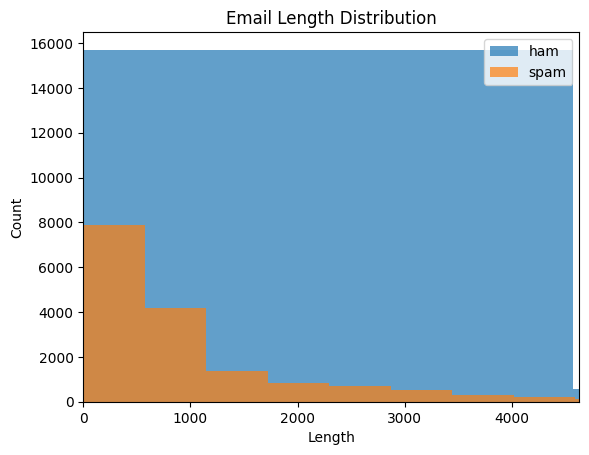

In [29]:
import matplotlib.pyplot as plt

columnName = "Spam/Ham"

df['text_length'] = df['Message'].apply(len)

# Plot distribution of text length
plt.hist(df[df[columnName] == 'ham']['text_length'], bins=50, alpha=0.7, label='ham')
plt.hist(df[df[columnName] == 'spam']['text_length'], bins=50, alpha=0.7, label='spam')
plt.title('Email Length Distribution')

plt.xlabel('Length')
upper_limit = df['text_length'].quantile(0.95)
plt.xlim(0, upper_limit)

plt.ylabel('Count')
plt.legend()
plt.show()

| Insight                | What we Learned                                                              | How It Helps in Next Steps                                                     |
| ---------------------- | ---------------------------------------------------------------------------- | ------------------------------------------------------------------------------ |
| **Missing Values**     | 371 rows missing `Message`, mostly spam                                      | We dropped them to avoid unusable inputs and skewing label balance             |
| **Class Distribution** | Roughly 50% spam, 50% ham                                                    | Data is fairly balanced, so no need for over/undersampling yet                 |
| **Text Length**        | Spam emails are generally **shorter**; ham emails are more varied and longer | `text_length` is a strong **feature** to include in your model                 |
| **Subject Missing**    | ~300 emails have no subject                                                  | We handled this with `fillna('')` to allow safe string operations              |
| **Length Overlap**     | There is overlap between spam and ham                                        | Indicates that **length alone is not enough**, but still useful in combination |
| **Outliers**           | Some emails are extremely long                                               | Suggests we may want to **cap** or **normalize** length-based features         |
